# Second Encoder

The primary change here will be the separation criteria that we will use, rather than just ionization mode we will also differentiate by instrument type. 

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

### Data Upload and basic processing

In [2]:
# The 5/20 dataset with rat based toxicity data
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()

(4001, 16)


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','63.0228:0.177223 65.0386:5.629055 68.0495:0.4...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','90 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
1,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','63.0228:0.125979 65.0386:2.113734 68.0495:0.6...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','75 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
2,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','56.0496:0.115017 65.0386:0.970445 68.0495:1.0...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','60 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
3,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','51.0229:0.102992 56.0495:0.143820 65.0386:0.6...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','45 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
4,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','56.0496:0.482623 65.0385:0.377829 68.0495:2.5...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','30 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'


In [3]:
# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'N/A'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")
df3.head()

["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive


In [4]:
print(df3['Group'].nunique()) # 13
# 13 groups means a 13 way split
print(df3['Group'].unique())
# Now we want counts of each group
print(df3['Group'].value_counts())

13
['Q-Orbitrap-positive' 'Q-Orbitrap-negative' 'Q-TOF-positive'
 'LTQ-Orbitrap-positive' 'QQQ-positive' 'Q-TOF-negative'
 'LTQ-Orbitrap-negative' 'QQQ-negative' 'Other-positive' 'LTQ-negative'
 'QQQ-nan' 'LTQ-positive' 'Other-negative']
Group
Q-Orbitrap-positive      1307
Q-Orbitrap-negative       756
Q-TOF-positive            736
LTQ-Orbitrap-positive     481
QQQ-positive              253
Q-TOF-negative            188
QQQ-negative               85
Other-positive             71
LTQ-Orbitrap-negative      63
LTQ-positive               19
QQQ-nan                    18
Other-negative             13
LTQ-negative               11
Name: count, dtype: int64


### Data Split

This split is a little bit less straightfoward since we need to divide into many many classes rather than just two so we will need a more rigorous naming system in place.

Notice that in this case we needn't do a positive negative split since that split is aready included inthe group differentiation.
- Q-Orbitrap-positive      1307 --> QQpos
- Q-Orbitrap-negative       756 --> QQneg
- Q-TOF-positive            736 --> QTOFpos
- LTQ-Orbitrap-positive     481 --> LTQOpos
- QQQ-positive              253 --> QQQpos
- Q-TOF-negative            188 --> QTOFneg
- QQQ-negative               85 --> QQQneg
- Other-positive             71 --> Opos
- LTQ-Orbitrap-negative      63 --> LTQOneg
- LTQ-positive               19 --> LTQpos
- QQQ-nan                    18 --> QQQnan
- Other-negative             13 --> Oneg
- LTQ-negative               11 --> LTQneg

As before we will need to convert spectra strings to dataframes that we can then bin.

In [ ]:
# Data split based on the 'Group' column
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive'] # 736  
df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481
df3_QQQpos = df3[df3['Group'] == 'QQQ-positive'] # 253
df3_QTOFneg = df3[df3['Group'] == 'Q-TOF-negative'] # 188 

# With these there may not be enough data to train a model
df3_QQQneg = df3[df3['Group'] == 'QQQ-negative'] # 85
df3_Opos = df3[df3['Group'] == 'Other-positive'] # 71
df3_LTQOneg = df3[df3['Group'] == 'LTQ-Orbitrap-negative'] # 63
df3_LTQpos = df3[df3['Group'] == 'LTQ-positive'] # 19
df3_QQQnan = df3[df3['Group'] == 'QQQ-nan'] # 18
df3_Oneg = df3[df3['Group'] == 'Other-negative'] # 13
df3_LTQneg = df3[df3['Group'] == 'LTQ-negative'] # 11

In [6]:
# First define the function we will use
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

In [7]:
df3_QQpos.head()

,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive


### Binning

In [8]:
# First lets include the binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [9]:
df3_QQpos_matrix = spectrum_string_to_dataframe(df3_QQpos,'Spectrum', 'SMILES_spectra')
df3_QQpos_spectra = df3_QQpos_matrix

In [ ]:
# Keep the first column as is, convert the rest to float
cols = df3_QQpos_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QQpos_spectra.columns = new_cols

In [11]:
# Convert all elements except the first column to float
df3_QQpos_spectra.iloc[:, 1:] = df3_QQpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

In [12]:
all_float = all(isinstance(c, float) for c in df3_QQpos_spectra.columns[1:])
print("All columns are float:", all_float)

# Select all columns except the first
spectra = df3_QQpos_spectra.iloc[:, 1:]

# Check if every element is a float
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)

All columns are float: True
All elements are float: True


In [ ]:
# Sort columns by float value, keep the first column (SMILES) first
cols = df3_QQpos_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_QQpos_spectra = df3_QQpos_spectra[sorted_cols]

In [14]:
# Look at the column maximums
max_col_pos = max(df3_QQpos_spectra.columns[1:])
print("Largest column name (m/z):", max_col_pos)
max_col_neg = max(df3_QQpos_spectra.columns[1:])
print("Largest column name (m/z):", max_col_neg)

# Look at the column minimums
min_col_pos = min(df3_QQpos_spectra.columns[1:])
print("Smallest column name (m/z):", min_col_pos)
min_col_neg = min(df3_QQpos_spectra.columns[1:])
print("Smallest column name (m/z):", min_col_neg)

Largest column name (m/z): 679.4382
Largest column name (m/z): 679.4382
Smallest column name (m/z): 49.5027114573
Smallest column name (m/z): 49.5027114573


In [15]:
# Use the binning function on the df3_QQpos_spectra mode spectra
binned_df3_QQpos_spectra = bin_spectra_by_integer_mz(df3_QQpos_spectra)
binned_df3_QQpos_spectra_filled = fill_missing_integer_columns(binned_df3_QQpos_spectra)
binned_df3_QQpos_spectra_filled.head()

/tmp/ipykernel_74597/954985155.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  binned.insert(0, smiles_col, df[smiles_col])
/tmp/ipykernel_74597/954985155.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = 0.0
/tmp/ipykernel_74597/954985155.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,670,671,672,673,674,675,676,677,678,679
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# Save the binned spectra to a CSV file
#binned_df3_QQpos_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv", index=False)

### ChemNet data

In [17]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [18]:
ChemNet_of_df3_QQpos_no_repeats_dict = get_chemnet_emb_from_smiles(df3_QQpos_spectra["SMILES_spectra"])

/home/dlipsey/.local/lib/python3.8/site-packages/fcd_torch/fcd.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  keras_config = torch.load(model_path)


In [19]:
ChemNet_of_df3_QQpos_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_QQpos_no_repeats_dict, orient='index')
ChemNet_of_df3_QQpos_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_QQpos_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

In [20]:
# Save ChemNet embeddings to a CSV file
#ChemNet_of_df3_QQpos_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv", index=False)

## Encoder: Functions and architecture

In [21]:
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

In [22]:
# Training and validation dataset split for the positive ionization mode
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
# Count occurrences of each SMILES_spectra
counts = df3_QQpos_spectra['SMILES_spectra'].value_counts()
# Keep only SMILES_spectra with at least 4 entries
valid_smiles = counts[counts >= 4].index
filtered_df3_QQpos_spectra = df3_QQpos_spectra[df3_QQpos_spectra['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_df3_QQpos_spectra.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_df3_QQpos_spectra.loc[train_indices].reset_index(drop=True)
test_data = filtered_df3_QQpos_spectra.loc[test_indices].reset_index(drop=True)

# Add an 'index' column for downstream compatibility
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

train_data.head()
print(type(train_data))
train_data_copy = train_data.copy()
print(type(train_data_copy))
print(train_data['SMILES_spectra'].value_counts())

(609, 681)
(579, 681)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
SMILES_spectra
CN1N(C(=O)C=C1C)C1=CC=CC=C1                14
OCC(O)C(O)C(O)CO                           13
CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2         11
CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC        11
CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1    11
                                           ..
CCN(CC)CC(=O)NC1=C(C)C=CC=C1C               3
CCN1C2=C(C=CC=C2)C2=C1C=CC(N)=C2            3
CCNC1=NC(NC(C)C)=NC(OC)=N1                  3
CCSCC1=C(OC(=O)NC)C=CC=C1                   3
CC1=CN([C@@H]2O[C@H](CO)C=C2)C(=O)NC1=O     2
Name: count, Length: 166, dtype: int64


In [23]:
# Special Modificaiton of test set: remove CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2
# Remove the specified SMILES from the train set
smiles_to_remove = "CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2"
train_data = train_data[train_data['SMILES_spectra'] != smiles_to_remove].copy()
test_data_copy = test_data.copy()
print("After removal:", train_data.shape)
print("Still present?", smiles_to_remove in train_data['SMILES_spectra'].values)
train_data_copy = train_data.copy()
test_data = test_data[test_data['SMILES_spectra'] != smiles_to_remove].copy()

print("After removal:", test_data.shape)
print("Still present?", smiles_to_remove in test_data['SMILES_spectra'].values)

After removal: (598, 681)
Still present? False
After removal: (569, 681)
Still present? False


In [24]:
# Input the Encoder file
#%% 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

#%% 
# This cell needs to be updated with your own paths/requirements
batch_size = 64

# Train and validation datasets are determined by the above code
train_data = train_data
# train_data = pd.read_csv("/") 
val_data = test_data
# val_data = pd.read_csv(" ") 

# Chemical names and ChemNet embeddings
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 10

In [25]:
#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Encoder: Training

In [26]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model = train_model(
    model=encoder,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 24203.0 MB
  Memory Used: 14.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


/tmp/ipykernel_74597/3365415882.py:37: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)


Epoch [1/500]
   Training loss: 0.09039279446005821
   Validation loss: 0.018004192039370537
Epoch [2/500]
   Training loss: 0.08287466168403626
   Validation loss: 0.016732143238186836
Epoch [3/500]
   Training loss: 0.07230692282319069
   Validation loss: 0.01463670190423727
Epoch [4/500]
   Training loss: 0.06769624054431915
   Validation loss: 0.01401054859161377
Epoch [5/500]
   Training loss: 0.06495214328169822
   Validation loss: 0.013000997714698315
Epoch [6/500]
   Training loss: 0.06456282362341881
   Validation loss: 0.013339580968022346
Epoch [7/500]
   Training loss: 0.06351519040763379
   Validation loss: 0.012011859565973282
Epoch [8/500]
   Training loss: 0.06409513764083385
   Validation loss: 0.013389361090958118
Epoch [9/500]
   Training loss: 0.0639132797718048
   Validation loss: 0.013250610791146755
Epoch [10/500]
   Training loss: 0.06367863640189171
   Validation loss: 0.012893818318843842
Epoch [11/500]
   Training loss: 0.06329931616783142
   Validation loss:

In [27]:
# Encoder excecution
encoder.eval()
with torch.no_grad():
    test_output = encoder(x_val)  # output.shape will be (batch_size, 512)

with torch.no_grad():
    train_output = encoder(x_train)  # output.shape will be (batch_size, 512)

### PCA Plots of encoder outputs

In [28]:
# Mapping from SMILES to Response
smiles_to_response = df3_QQpos.drop_duplicates(subset='SMILES_spectra').set_index('SMILES_spectra')['Response']

# Ouptput dataframe
test_output_np = test_output.cpu().numpy()
test_output_df = pd.DataFrame(test_output_np)
test_output_df['SMILES_spectra'] = test_data['SMILES_spectra'].values  # 1:1 with test_data
cols = test_output_df.columns.tolist()
test_output_df = test_output_df[['SMILES_spectra'] + [c for c in cols if c != 'SMILES_spectra']]
test_output_df['Response'] = test_output_df['SMILES_spectra'].map(smiles_to_response)

# Check the output
print(test_output_df.shape)
print(test_output_df['SMILES_spectra'].value_counts())

(569, 514)
SMILES_spectra
OCC(O)C(O)C(O)CO                                  13
CN1N(C(=O)C=C1C)C1=CC=CC=C1                       13
CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC               10
OCC(O)C(O)C(O)C(O)CO                              10
CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1           10
                                                  ..
N(C1=CC=CC=C1)C1=CC=C2C=CC=CC2=C1                  2
CCN(CC)CC(=O)NC1=C(C)C=CC=C1C                      2
COc1ccc(CN(CCN(C)C)c2ccccn2)cc1                    2
ClC1=CC=CC(=C1)N1CCN(CCCN2N=C3C=CC=CN3C2=O)CC1     2
ClCCNP1(=O)OCCCN1CCCl                              2
Name: count, Length: 165, dtype: int64


In [29]:
test_output_df.head()

,SMILES_spectra,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C#CCN(C)Cc1ccccc1,-0.088861,0.025085,-0.139154,0.376713,0.007613,0.062717,-0.087648,-0.673419,-0.615346,...,0.807606,0.746650,0.012291,-0.241487,-0.289414,-0.574204,0.044893,0.059158,0.226820,273.642508
1,C#CCN(C)Cc1ccccc1,-0.079555,0.023674,-0.167939,0.354421,-0.003732,0.048294,-0.102269,-0.692035,-0.601392,...,0.794070,0.717172,0.029871,-0.258831,-0.284689,-0.544803,0.052407,0.055126,0.211960,273.642508
2,C#CCN(C)Cc1ccccc1,-0.083262,0.016797,-0.152143,0.326374,-0.007804,0.058299,-0.062892,-0.668562,-0.595274,...,0.816475,0.715695,0.020918,-0.236970,-0.257234,-0.563135,0.064635,0.079602,0.218450,273.642508
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.047343,-0.068885,0.197597,0.429336,-0.111190,0.205835,-0.179264,-0.265070,-0.089632,...,0.298648,0.358237,0.045157,0.068649,0.044061,-0.044556,0.418142,0.187076,0.150177,5000.000000
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.348848,-0.024115,0.141571,0.695669,-0.111882,0.108507,-0.372239,-0.045221,0.036779,...,-0.336541,0.414351,-0.024902,0.104065,0.157383,0.358947,0.632847,0.131122,0.387437,5000.000000


In [30]:
# Train Ouptput dataframe
train_output_np = train_output.cpu().numpy()
train_output_df = pd.DataFrame(train_output_np)
train_output_df['SMILES_spectra'] = train_data_copy['SMILES_spectra'].values  # 1:1 with test_data
cols = train_output_df.columns.tolist()
train_output_df = train_output_df[['SMILES_spectra'] + [c for c in cols if c != 'SMILES_spectra']]
train_output_df['Response'] = train_output_df['SMILES_spectra'].map(smiles_to_response)

# Check the output
print(train_output_df.shape)
print(train_output_df['SMILES_spectra'].value_counts())

(598, 514)
SMILES_spectra
CN1N(C(=O)C=C1C)C1=CC=CC=C1                             14
OCC(O)C(O)C(O)CO                                        13
CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC                     11
CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1                 11
OCC(O)C(O)C(O)C(O)CO                                    10
                                                        ..
CCOC(=O)N1CCC(CC1)=C1C2=C(CCC3=C1N=CC=C3)C=C(Cl)C=C2     3
CCOC(=O)NC(=S)NC1=C(NC(=S)NC(=O)OCC)C=CC=C1              3
CCOC(=O)NNC1=NN=CC2=CC=CC=C12                            3
C#CCN(C)Cc1ccccc1                                        3
CC1=CN([C@@H]2O[C@H](CO)C=C2)C(=O)NC1=O                  2
Name: count, Length: 165, dtype: int64


In [31]:
train_output_df.head()

,SMILES_spectra,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C#CCN(C)Cc1ccccc1,-0.078642,0.021003,-0.078280,0.343090,-0.009076,0.067346,-0.012744,-0.598159,-0.590625,...,0.827254,0.699496,0.005370,-0.141843,-0.221250,-0.586250,0.049511,0.092663,0.236901,273.642508
1,C#CCN(C)Cc1ccccc1,-0.088646,0.024874,-0.138693,0.372434,0.007467,0.063039,-0.083479,-0.672563,-0.614910,...,0.809101,0.746876,0.011385,-0.239330,-0.286741,-0.576052,0.047168,0.061969,0.225802,273.642508
2,C#CCN(C)Cc1ccccc1,-0.080339,0.020549,-0.169266,0.330642,-0.006674,0.051689,-0.085711,-0.686863,-0.593790,...,0.801725,0.713324,0.026920,-0.252824,-0.269727,-0.547650,0.067004,0.069861,0.206639,273.642508
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.364925,0.000949,0.089488,0.614808,-0.126016,0.131437,-0.357201,-0.048260,0.030532,...,-0.347714,0.447183,-0.001078,0.111467,0.188134,0.348255,0.589162,0.152843,0.362405,5000.000000
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.339472,-0.001637,0.102680,0.628031,-0.113403,0.105124,-0.376148,-0.052287,0.026893,...,-0.332457,0.414950,-0.016183,0.117489,0.191529,0.349500,0.578941,0.142182,0.375915,5000.000000


In [32]:
# Find SMILES_spectra with 'occurances' or fewer/more occurrences
occurances = 10 # This can be changed

# Combine train and test for counting
all_smiles = pd.concat([train_output_df['SMILES_spectra'], test_output_df['SMILES_spectra']])
all_counts = all_smiles.value_counts()
selected_smiles = all_counts[all_counts >= occurances].index # More than or equal to 'occurances'
# selected_smiles = all_counts[all_counts <= occurances].index # Less than or equal to 'occurances'

# Subset both train and test to only those SMILES
train_output_df_sub = train_output_df[train_output_df['SMILES_spectra'].isin(selected_smiles)].copy()
test_output_df_sub = test_output_df[test_output_df['SMILES_spectra'].isin(selected_smiles)].copy()

print(train_output_df_sub['SMILES_spectra'].nunique())
print(test_output_df_sub['SMILES_spectra'].nunique())
print(train_output_df_sub.shape)
print(test_output_df_sub.shape)
print("Number of unique SMILES_spectra in train:", train_output_df_sub['SMILES_spectra'].nunique())
print("Number of unique SMILES_spectra in test:", test_output_df_sub['SMILES_spectra'].nunique())


17
17
(144, 514)
(136, 514)
Number of unique SMILES_spectra in train: 17
Number of unique SMILES_spectra in test: 17


In [33]:
# Upload the Chemnet embeddings dataframe to provide true embeddings 
ChemNet_of_df3_QQpos_no_repeats = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

# Get the unique SMILES_spectra for the subset
sub_smiles_set = set(test_output_df_sub['SMILES_spectra'].unique()) # With a unique dataframe this isn't strictly necessary

# Subset ChemNet_of_df2pos_no_repeats to only those SMILES
chemnet_sub = ChemNet_of_df3_QQpos_no_repeats[ChemNet_of_df3_QQpos_no_repeats['SMILES'].isin(sub_smiles_set)].copy()

# Merge with the Response column from df2 to get toxicity values
chemnet_sub = chemnet_sub.merge(
    df3[['SMILES_spectra', 'Response']],
    left_on='SMILES',
    right_on='SMILES_spectra',
    how='left'
)
# Remove the SMILES_spectra column after merging as it's redundant
chemnet_sub = chemnet_sub.drop(columns=['SMILES_spectra'])

# Keep only one row per unique SMILES (first occurrence)
chemnet_sub= chemnet_sub.drop_duplicates(subset='SMILES').copy()

# Check
print(chemnet_sub.shape)
chemnet_sub.head()


(17, 514)


,SMILES,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C=C(C)C1CC=C(C)CC1,-0.116176,0.002966,-0.023850,-0.103578,-0.038338,0.042710,-0.245518,-0.157546,-0.201870,...,-0.082871,0.135509,0.000010,-0.498958,-0.144333,0.012490,-0.220284,0.061193,-0.347721,4825.080312
16,CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12,-0.596011,0.012174,-0.218746,0.144652,-0.009223,0.035933,-0.010077,-0.082254,-0.453001,...,0.933405,0.003413,-0.011088,0.026218,-0.015641,-0.085272,0.388240,0.057477,0.563751,400.000000
58,CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1,0.196781,0.008724,-0.294192,-0.471313,-0.281907,0.136417,-0.378564,-0.379551,-0.036421,...,0.019482,0.902094,-0.000209,-0.130971,-0.126209,-0.417062,0.312234,0.127192,0.182647,12500.000000
109,CC1=CC(=O)OC2=C1C=CC(O)=C2,0.320358,0.005968,-0.541099,0.010104,-0.225100,0.035888,0.343417,0.109103,-0.006698,...,-0.256850,0.933564,-0.000021,0.006631,-0.023242,-0.445357,0.339883,0.245815,-0.026356,3850.000000
134,CCCCCCCC(=O)OCC(COC(=O)CCCCCCC)OC(=O)CCCCCCC,0.291447,0.011824,-0.107934,-0.429980,-0.458429,0.391239,0.048168,-0.126499,-0.195105,...,-0.082579,0.009040,-0.000008,-0.057635,-0.005315,0.186953,0.186397,-0.268054,0.111695,33276.635020


In [34]:
# Create tox_epa12 column based on Response
test_output_df_sub['tox_epa12'] = (test_output_df_sub['Response'] <= 500).astype(int)
train_output_df_sub['tox_epa12'] = (train_output_df_sub['Response'] <= 500).astype(int)
chemnet_sub['tox_epa12'] = (chemnet_sub['Response'] <= 500).astype(int)

# Check the disribution
print(test_output_df_sub['tox_epa12'].value_counts())
print(train_output_df_sub['tox_epa12'].value_counts())
print(chemnet_sub['tox_epa12'].value_counts())

tox_epa12
0    122
1     14
Name: count, dtype: int64
tox_epa12
0    128
1     16
Name: count, dtype: int64
tox_epa12
0    15
1     2
Name: count, dtype: int64


### PCA plots

In [35]:
# Functions in plotting procedure
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# Isolate the embedding columns
def get_embedding_columns(df):
    # Select all columns except the first and last by index
    return df.columns[1:-2].tolist()

# Outlier removal function after PCA
def remove_outliers_on_axes(df, pc1_col, pc2_col, n_low_pc1=0, n_high_pc1=0, n_low_pc2=0, n_high_pc2=0):
    # Remove outliers on PC2
    df = df.sort_values(pc2_col, ascending=True)
    if n_low_pc2 > 0:
        df = df.iloc[n_low_pc2:]
    if n_high_pc2 > 0:
        df = df.iloc[:-n_high_pc2]
    # Remove outliers on PC1
    df = df.sort_values(pc1_col, ascending=True)
    if n_low_pc1 > 0:
        df = df.iloc[n_low_pc1:]
    if n_high_pc1 > 0:
        df = df.iloc[:-n_high_pc1]
    return df


# Outlier removal function before PCA
def remove_outliers_by_column(df, col, n_low=0, n_high=0):
    df_sorted = df.sort_values(col, ascending=True)
    if n_high > 0:
        df_sorted = df_sorted.iloc[:-n_high]
    if n_low > 0:
        df_sorted = df_sorted.iloc[n_low:]
    return df_sorted

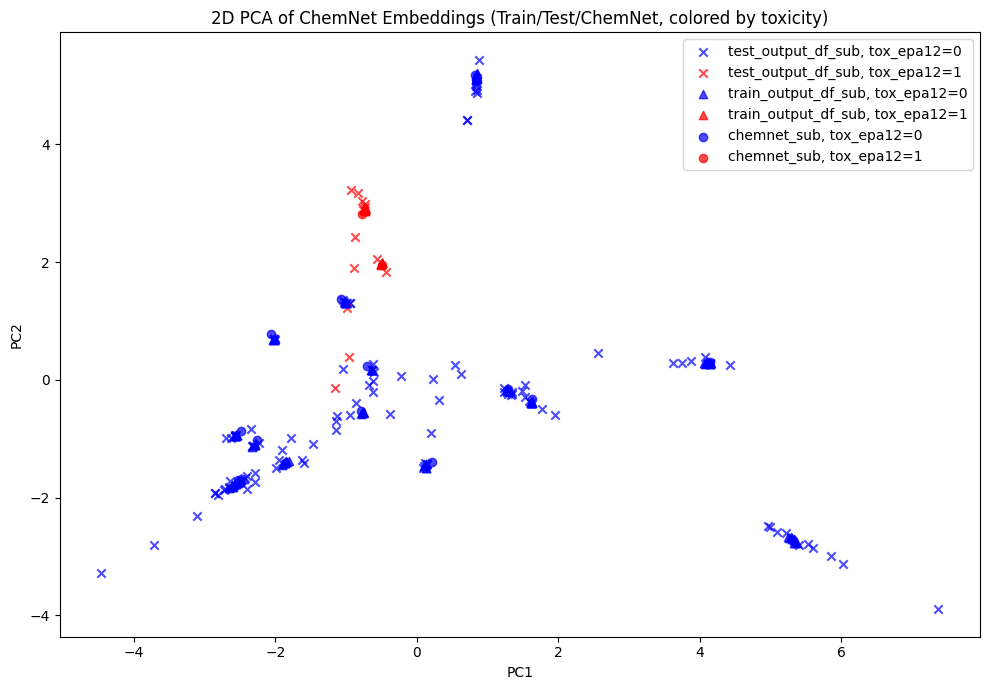

In [36]:
# PCA plot, color by toxicity (with train data plotted)

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
X_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Plot
plt.figure(figsize=(10,7))

# Output (test) points
mask_test_output_red = test_output_df_sub['tox_epa12'] == 1
mask_test_output_blue = test_output_df_sub['tox_epa12'] == 0
plt.scatter(X_output_pca[mask_test_output_blue,0], X_output_pca[mask_test_output_blue,1], 
            c='blue', marker='x', label='test_output_df_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_output_pca[mask_test_output_red,0], X_output_pca[mask_test_output_red,1], 
            c='red', marker='x', label='test_output_df_sub, tox_epa12=1', alpha=0.7)

# Train points
mask_train_red = train_output_df_sub['tox_epa12'] == 1
mask_train_blue = train_output_df_sub['tox_epa12'] == 0
plt.scatter(X_train_output_pca[mask_train_blue,0], X_train_output_pca[mask_train_blue,1], 
            c='blue', marker='^', label='train_output_df_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_train_output_pca[mask_train_red,0], X_train_output_pca[mask_train_red,1], 
            c='red', marker='^', label='train_output_df_sub, tox_epa12=1', alpha=0.7)

# ChemNet points
mask_chemnet_red = chemnet_sub['tox_epa12'] == 1
mask_chemnet_blue = chemnet_sub['tox_epa12'] == 0
plt.scatter(X_chemnet_pca[mask_chemnet_blue,0], X_chemnet_pca[mask_chemnet_blue,1], 
            c='blue', marker='o', label='chemnet_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_chemnet_pca[mask_chemnet_red,0], X_chemnet_pca[mask_chemnet_red,1], 
            c='red', marker='o', label='chemnet_sub, tox_epa12=1', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test/ChemNet, colored by toxicity)')
plt.legend()
plt.tight_layout()
plt.show()

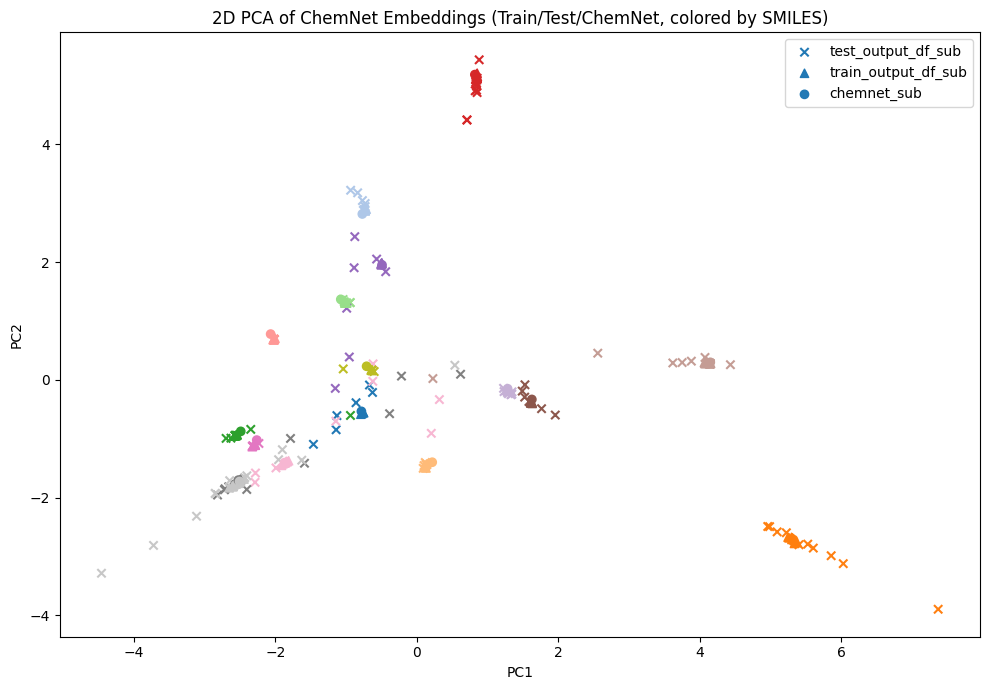

In [37]:
# PCA plot, color by SMILES (with train data plotted)

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split 
X_test_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Assign colors to unique SMILES
all_smiles = pd.concat([
    test_output_df_sub['SMILES_spectra'],
    train_output_df_sub['SMILES_spectra'],
    chemnet_sub['SMILES']
]).unique()
color_map = {smiles: cm.tab20(i % 20) for i, smiles in enumerate(all_smiles)}

output_colors = test_output_df_sub['SMILES_spectra'].map(color_map)
train_colors = train_output_df_sub['SMILES_spectra'].map(color_map)
chemnet_colors = chemnet_sub['SMILES'].map(color_map)

# Plot
plt.figure(figsize=(10,7))

plt.scatter(X_output_pca[:,0], X_output_pca[:,1], 
            c=output_colors, marker='x', label='test_output_df_sub', alpha=0.99)
plt.scatter(X_train_output_pca[:,0], X_train_output_pca[:,1], 
            c=train_colors, marker='^', label='train_output_df_sub', alpha=0.99)
plt.scatter(X_chemnet_pca[:,0], X_chemnet_pca[:,1], 
            c=chemnet_colors, marker='o', label='chemnet_sub', alpha=0.99)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test/ChemNet, colored by SMILES)')
plt.tight_layout()
plt.legend()
plt.show()

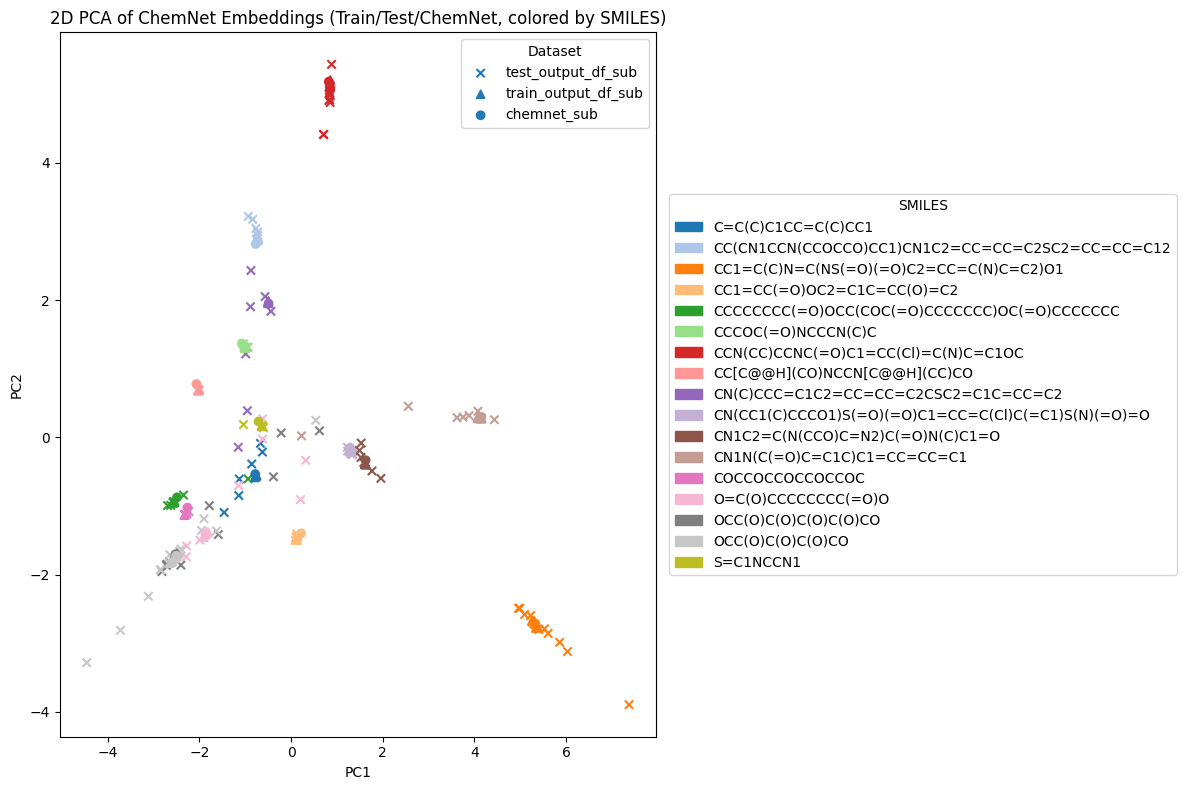

In [38]:
# PCA plot, color by SMILES (with train data plotted and SMILES legend)

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
X_test_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Assign colors to unique SMILES
all_smiles = pd.concat([
    test_output_df_sub['SMILES_spectra'],
    train_output_df_sub['SMILES_spectra'],
    chemnet_sub['SMILES']
]).unique()
color_map = {smiles: cm.tab20(i % 20) for i, smiles in enumerate(all_smiles)}

test_output_colors = test_output_df_sub['SMILES_spectra'].map(color_map)
train_colors = train_output_df_sub['SMILES_spectra'].map(color_map)
chemnet_colors = chemnet_sub['SMILES'].map(color_map)

plt.figure(figsize=(12,8))

plt.scatter(X_test_output_pca[:,0], X_test_output_pca[:,1], 
            c=test_output_colors, marker='x', label='test_output_df_sub', alpha=0.99)
plt.scatter(X_train_output_pca[:,0], X_train_output_pca[:,1], 
            c=train_colors, marker='^', label='train_output_df_sub', alpha=0.99)
plt.scatter(X_chemnet_pca[:,0], X_chemnet_pca[:,1], 
            c=chemnet_colors, marker='o', label='chemnet_sub', alpha=0.99)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test/ChemNet, colored by SMILES)')

# First legend: dataset markers (handles only)
handles, labels = plt.gca().get_legend_handles_labels()
legend1 = plt.legend(handles, labels, loc='upper right', title='Dataset')

# Second legend: SMILES color mapping (show up to 20 for clarity)
max_smiles_legend = 20
smiles_legend_patches = [
    mpatches.Patch(color=color_map[smiles], label=smiles)
    for i, smiles in enumerate(all_smiles[:max_smiles_legend])
]
legend2 = plt.legend(handles=smiles_legend_patches, title="SMILES", loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.gca().add_artist(legend1)  # Add the first legend back

plt.tight_layout()
plt.show()

### Super Testing

In [39]:
# Define super-test set
super_train = train_data_copy[train_data_copy['SMILES_spectra'] == smiles_to_remove].copy()
super_test = test_data_copy[test_data_copy['SMILES_spectra'] == smiles_to_remove].copy()
# Combine super_test and super_train into one DataFrame
super_combined = pd.concat([super_test, super_train], ignore_index=True)

# Prepare the spectra features for the encoder (assuming same columns as x_val/x_train)
# If you have a function to create tensors, use it here; otherwise, select the correct columns:
spectra_cols = x_val.shape[1]  # number of features used for encoder
X_super = super_combined.iloc[:, 1:1+spectra_cols].values  # adjust column selection as needed

X_super_tensor = torch.tensor(X_super, dtype=torch.float32).to(x_val.device)

# Encoder execution
encoder.eval()
with torch.no_grad():
    super_output = encoder(X_super_tensor)  # output.shape will be (num_super, 512)

print(super_output.shape)

torch.Size([10, 512])


In [40]:
# Delete the last column from super_combined
#super_combined = super_combined.iloc[:, :-1]
# Map the Response value from test_data using SMILES_spectra (all values will be the same for this SMILES)
response_value = df3_QQpos[df3_QQpos['SMILES_spectra'] == smiles_to_remove]['Response'].iloc[0]
super_combined['Response'] = response_value
super_combined.head()


,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,672,673,674,675,676,677,678,679,index,Response
0,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,377,375.0
1,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,378,375.0
2,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,379,375.0
3,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,380,375.0
4,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,381,375.0


In [41]:
# Train Ouptput dataframe
super_output_np = super_output.cpu().numpy()
# Convert super_output (tensor) to a DataFrame
super_output_df = pd.DataFrame(super_output.cpu().numpy())

# Add the 'SMILES_spectra' and 'Response' columns from super_combined
super_output_df['SMILES_spectra'] = super_combined['SMILES_spectra'].values
super_output_df['Response'] = super_combined['Response'].values
# Check the output
print(super_output_df.shape)
print(super_output_df['SMILES_spectra'].value_counts())

(10, 514)
SMILES_spectra
CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2    10
Name: count, dtype: int64


In [42]:
super_output_chemnet = ChemNet_of_df3_QQpos_no_repeats[ChemNet_of_df3_QQpos_no_repeats['SMILES'].isin(super_output_df['SMILES_spectra'])].copy()

In [43]:
# Take the unique Response value from super_output_df and assign it to all rows in super_output_chemnet
response_value = super_output_df['Response'].iloc[0]
super_output_chemnet['Response'] = response_value

In [44]:
super_output_chemnet.head()

,SMILES,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
164,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,-0.34026,0.008974,-0.025661,0.200381,-0.013478,0.007453,-0.148696,-0.283553,-0.14953,...,0.586886,0.081946,-0.005927,-0.270065,-0.090165,-0.338759,0.530879,0.014117,0.042204,375.0


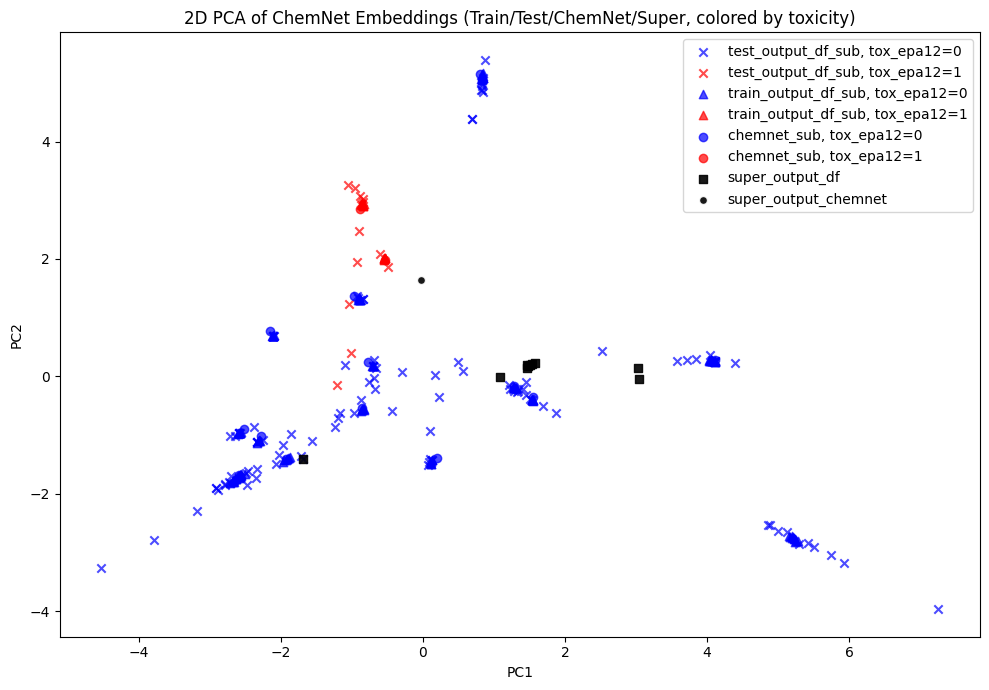

In [45]:
# PCA plot, color by toxicity (with train data plotted and super ChemNet as black circle)

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)
emb_cols_super_output = super_output_df.columns[:-2]  # exclude SMILES_spectra and Response
emb_cols_super_chemnet = super_output_chemnet.columns[1:-1]

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values
X_super_output = super_output_df[emb_cols_super_output].values
X_super_output_chemnet = super_output_chemnet[emb_cols_super_chemnet].values

# Combine for PCA fit (add super_output at the end)
X_all = np.vstack([X_test_output, X_train_output, X_chemnet, X_super_output, X_super_output_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
n_test = len(test_output_df_sub)
n_train = len(train_output_df_sub)
n_chemnet = len(chemnet_sub)
n_super = len(super_output_df)
n_super_chemnet = len(super_output_chemnet)

X_output_pca = X_all_pca[:n_test]
X_train_output_pca = X_all_pca[n_test:n_test + n_train]
X_chemnet_pca = X_all_pca[n_test + n_train:n_test + n_train + n_chemnet]
X_super_output_pca = X_all_pca[n_test + n_train + n_chemnet:n_test + n_train + n_chemnet + n_super]
X_super_output_chemnet_pca = X_all_pca[-n_super_chemnet:]

plt.figure(figsize=(10,7))

# Output (test) points
mask_test_output_red = test_output_df_sub['tox_epa12'] == 1
mask_test_output_blue = test_output_df_sub['tox_epa12'] == 0
plt.scatter(X_output_pca[mask_test_output_blue,0], X_output_pca[mask_test_output_blue,1], 
            c='blue', marker='x', label='test_output_df_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_output_pca[mask_test_output_red,0], X_output_pca[mask_test_output_red,1], 
            c='red', marker='x', label='test_output_df_sub, tox_epa12=1', alpha=0.7)

# Train points
mask_train_red = train_output_df_sub['tox_epa12'] == 1
mask_train_blue = train_output_df_sub['tox_epa12'] == 0
plt.scatter(X_train_output_pca[mask_train_blue,0], X_train_output_pca[mask_train_blue,1], 
            c='blue', marker='^', label='train_output_df_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_train_output_pca[mask_train_red,0], X_train_output_pca[mask_train_red,1], 
            c='red', marker='^', label='train_output_df_sub, tox_epa12=1', alpha=0.7)

# ChemNet points
mask_chemnet_red = chemnet_sub['tox_epa12'] == 1
mask_chemnet_blue = chemnet_sub['tox_epa12'] == 0
plt.scatter(X_chemnet_pca[mask_chemnet_blue,0], X_chemnet_pca[mask_chemnet_blue,1], 
            c='blue', marker='o', label='chemnet_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_chemnet_pca[mask_chemnet_red,0], X_chemnet_pca[mask_chemnet_red,1], 
            c='red', marker='o', label='chemnet_sub, tox_epa12=1', alpha=0.7)

# Super output points (all black squares)
plt.scatter(X_super_output_pca[:,0], X_super_output_pca[:,1], 
            c='black', marker='s', label='super_output_df', alpha=0.9)

# Super ChemNet points (all black circles)
plt.scatter(X_super_output_chemnet_pca[:,0], X_super_output_chemnet_pca[:,1], 
            c='black', marker='o', label='super_output_chemnet', alpha=0.9, edgecolor='white', linewidth=1.2)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test/ChemNet/Super, colored by toxicity)')
plt.legend()
plt.tight_layout()
plt.show()

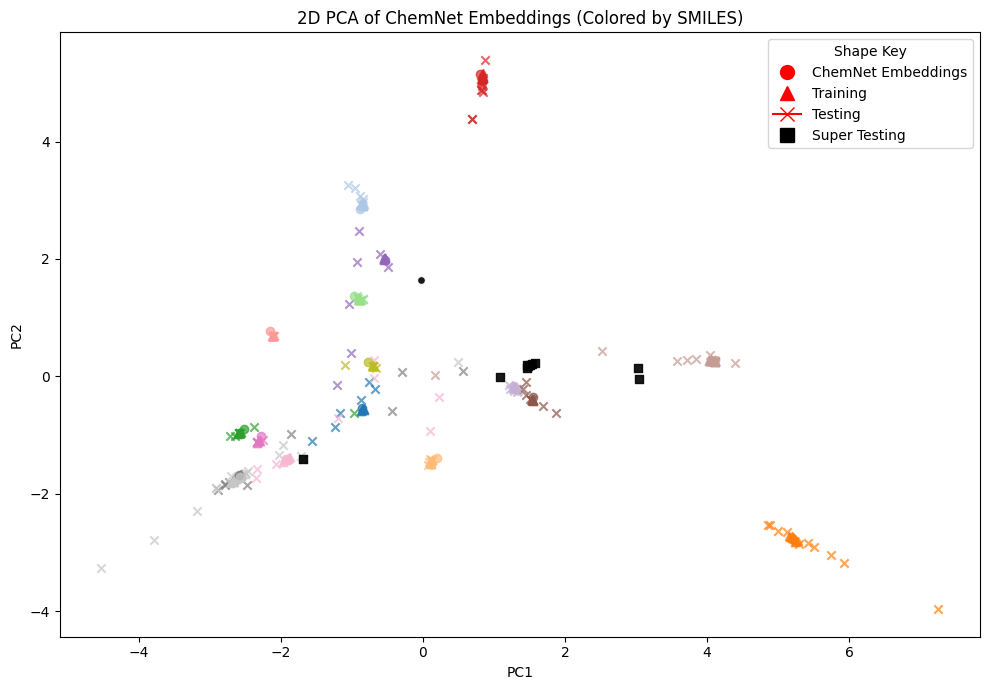

In [46]:
from matplotlib.lines import Line2D

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)
emb_cols_super_output = super_output_df.columns[:-2]  # exclude SMILES_spectra and Response
emb_cols_super_chemnet = super_output_chemnet.columns[1:-1]

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values
X_super_output = super_output_df[emb_cols_super_output].values
X_super_output_chemnet = super_output_chemnet[emb_cols_super_chemnet].values

# Combine for PCA fit (add super_output at the end)
X_all = np.vstack([X_test_output, X_train_output, X_chemnet, X_super_output, X_super_output_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
n_test = len(test_output_df_sub)
n_train = len(train_output_df_sub)
n_chemnet = len(chemnet_sub)
n_super = len(super_output_df)
n_super_chemnet = len(super_output_chemnet)

X_test_output_pca = X_all_pca[:n_test]
X_train_output_pca = X_all_pca[n_test:n_test + n_train]
X_chemnet_pca = X_all_pca[n_test + n_train:n_test + n_train + n_chemnet]
X_super_output_pca = X_all_pca[n_test + n_train + n_chemnet:n_test + n_train + n_chemnet + n_super]
X_super_output_chemnet_pca = X_all_pca[-n_super_chemnet:]

# Assign a color to each unique SMILES (except the super SMILES, which will be black)
all_smiles = pd.concat([
    test_output_df_sub['SMILES_spectra'],
    train_output_df_sub['SMILES_spectra'],
    chemnet_sub['SMILES']
]).unique()
super_smiles = super_output_df['SMILES_spectra'].iloc[0]
color_map = {smiles: cm.tab20(i % 20) for i, smiles in enumerate(all_smiles) if smiles != super_smiles}

plt.figure(figsize=(10,7))

# Plot test set by SMILES
for smiles in test_output_df_sub['SMILES_spectra'].unique():
    mask = test_output_df_sub['SMILES_spectra'] == smiles
    color = 'black' if smiles == super_smiles else color_map[smiles]
    plt.scatter(
        X_test_output_pca[mask, 0], X_test_output_pca[mask, 1],
        c=[color], marker='x', alpha=0.7
    )

# Plot train set by SMILES
for smiles in train_output_df_sub['SMILES_spectra'].unique():
    mask = train_output_df_sub['SMILES_spectra'] == smiles
    color = 'black' if smiles == super_smiles else color_map[smiles]
    plt.scatter(
        X_train_output_pca[mask, 0], X_train_output_pca[mask, 1],
        c=[color], marker='^', alpha=0.7
    )

# Plot chemnet set by SMILES
for smiles in chemnet_sub['SMILES'].unique():
    mask = chemnet_sub['SMILES'] == smiles
    color = 'black' if smiles == super_smiles else color_map.get(smiles, 'grey')
    plt.scatter(
        X_chemnet_pca[mask, 0], X_chemnet_pca[mask, 1],
        c=[color], marker='o', alpha=0.7
    )

# Super output points (all black squares)
plt.scatter(X_super_output_pca[:,0], X_super_output_pca[:,1], 
            c='black', marker='s', label='super_output_df', alpha=0.9)

# Super ChemNet points (all black circles)
plt.scatter(X_super_output_chemnet_pca[:,0], X_super_output_chemnet_pca[:,1], 
            c='black', marker='o', label='super_output_chemnet', alpha=0.9, edgecolor='white', linewidth=1.2)

# Add a shape legend only
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='ChemNet Embeddings', markerfacecolor='red', markeredgecolor='red', markersize=10),
    Line2D([0], [0], marker='^', color='w', label='Training', markerfacecolor='red', markeredgecolor='red', markersize=10),
    Line2D([0], [0], marker='x', color='red', label='Testing', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Super Testing', markerfacecolor='black', markeredgecolor='black', markersize=10)
]

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Colored by SMILES)')
plt.legend(handles=legend_elements, loc='upper right', title='Shape Key')
plt.tight_layout()
plt.show()

# Random Forest

## Random Forest on Spectra

In [47]:
# Load the needed packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score


### Data processing for Random Forest Classifier

In [48]:
print(train_output_df.shape)
print(test_output_df.shape)
print(ChemNet_of_df3_QQpos_no_repeats.shape)

(598, 514)
(569, 514)
(257, 513)


In [49]:
# SMILES removed: CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2

# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"

def assign_epa_level_3_levels(response):
    if response <= 50:
        return "EPA_level_1_2"
    elif response <= 500:
        return "EPA_level_1_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"



In [50]:
ChemNet_of_df3_QQpos = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

# Merge with the Response column from df2 to get toxicity values
ChemNet_of_df3_QQpos_withtox = ChemNet_of_df3_QQpos.merge(
    df3[['SMILES_spectra', 'Response']],
    left_on='SMILES',
    right_on='SMILES_spectra',
    how='left'
)
# Remove the SMILES_spectra column after merging as it's redundant
ChemNet_of_df3_QQpos_withtox = ChemNet_of_df3_QQpos_withtox.drop(columns=['SMILES_spectra'])

# Keep only one row per unique SMILES (first occurrence)
ChemNet_of_df3_QQpos_withtox= ChemNet_of_df3_QQpos_withtox.drop_duplicates(subset='SMILES').copy()

# Check
print(ChemNet_of_df3_QQpos_withtox.shape)
ChemNet_of_df3_QQpos_withtox.head()

(257, 514)


,SMILES,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C#CCN(C)Cc1ccccc1,-0.081874,-0.000591,-0.115426,0.361963,-0.013773,0.068921,-0.079049,-0.639645,-0.616877,...,0.757486,0.757160,-1.206947e-04,-0.201054,-0.281426,-0.574889,0.037233,0.048520,0.227970,273.642508
6,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343494,0.000665,0.109528,0.623215,-0.109778,0.112946,-0.418191,-0.035476,-0.004837,...,-0.356015,0.435768,-1.227300e-03,0.135895,0.161929,0.331091,0.624196,0.150649,0.398507,5000.000000
18,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178073,0.005417,0.428171,0.479712,-0.162719,0.033272,-0.322656,-0.034891,-0.049518,...,0.204102,0.215906,-1.736291e-02,0.542236,0.477791,-0.102516,0.484791,0.349672,-0.029118,1640.000000
24,C1=CC(=CC=N1)C1=CC=NC=C1,0.340498,0.000491,-0.096003,0.602184,-0.004242,0.101529,0.200828,-0.061072,-0.239719,...,-0.191646,0.951772,8.518274e-07,-0.169939,-0.143715,-0.217223,-0.283386,0.141254,0.285106,172.000000
29,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172673,0.001336,0.185543,0.693660,-0.003303,0.163667,0.365009,-0.086592,-0.362325,...,0.117902,0.938238,-2.607757e-03,-0.428630,-0.166449,-0.151636,0.001726,0.223620,0.140640,1463.000000


In [51]:
# Initialize a new DataFrame for the EPA levels
ChemNet_of_df3_QQpos_epalevels = ChemNet_of_df3_QQpos_withtox.copy()

# Assign EPA levels
ChemNet_of_df3_QQpos_epalevels["EPA_level"] = ChemNet_of_df3_QQpos_withtox["Response"].apply(assign_epa_level)

# One hot encode the EPA_level column
ChemNet_of_df3_QQpos_epalevels = pd.get_dummies(ChemNet_of_df3_QQpos_epalevels, columns=["EPA_level"], prefix='',prefix_sep='')

# Convert boolean columns to int (1/0)
epa_cols = [col for col in ChemNet_of_df3_QQpos_epalevels.columns if col.startswith("EPA_level_")]
ChemNet_of_df3_QQpos_epalevels[epa_cols] = ChemNet_of_df3_QQpos_epalevels[epa_cols].astype(int)

# Remove the Response column
ChemNet_of_df3_QQpos_epalevels.drop(columns=["Response"], inplace=True)

# Check the shape and head of the DataFrame
print(ChemNet_of_df3_QQpos_epalevels.shape)
ChemNet_of_df3_QQpos_epalevels.head()

(257, 517)


,SMILES,0,1,2,3,4,5,6,7,8,...,506,507,508,509,510,511,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,-0.081874,-0.000591,-0.115426,0.361963,-0.013773,0.068921,-0.079049,-0.639645,-0.616877,...,-0.201054,-0.281426,-0.574889,0.037233,0.048520,0.227970,0,1,0,0
6,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343494,0.000665,0.109528,0.623215,-0.109778,0.112946,-0.418191,-0.035476,-0.004837,...,0.135895,0.161929,0.331091,0.624196,0.150649,0.398507,0,0,1,0
18,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178073,0.005417,0.428171,0.479712,-0.162719,0.033272,-0.322656,-0.034891,-0.049518,...,0.542236,0.477791,-0.102516,0.484791,0.349672,-0.029118,0,0,1,0
24,C1=CC(=CC=N1)C1=CC=NC=C1,0.340498,0.000491,-0.096003,0.602184,-0.004242,0.101529,0.200828,-0.061072,-0.239719,...,-0.169939,-0.143715,-0.217223,-0.283386,0.141254,0.285106,0,1,0,0
29,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172673,0.001336,0.185543,0.693660,-0.003303,0.163667,0.365009,-0.086592,-0.362325,...,-0.428630,-0.166449,-0.151636,0.001726,0.223620,0.140640,0,0,1,0


In [52]:
# Encoder excecution (NOT NEEDED UNLESS I WANT TO RERUN)
encoder.eval()
with torch.no_grad():
    test_output = encoder(x_val)  # output.shape will be (batch_size, 512)

smiles_to_response = df3_QQpos.drop_duplicates(subset='SMILES_spectra').set_index('SMILES_spectra')['Response']

# Ouptput dataframe
test_output_np = test_output.cpu().numpy()
test_output_df = pd.DataFrame(test_output_np)
test_output_df['SMILES_spectra'] = test_data['SMILES_spectra'].values  # 1:1 with test_data
cols = test_output_df.columns.tolist()
test_output_df = test_output_df[['SMILES_spectra'] + [c for c in cols if c != 'SMILES_spectra']]
test_output_df['Response'] = test_output_df['SMILES_spectra'].map(smiles_to_response)

In [53]:
# Initialize a new DataFrame for the EPA levels
test_output_df_withEPA = test_output_df.copy()

# Assign EPA levels
test_output_df_withEPA["EPA_level"] = test_output_df["Response"].apply(assign_epa_level)

# One hot encode the EPA_level column
test_output_df_withEPA = pd.get_dummies(test_output_df_withEPA, columns=["EPA_level"], prefix='',prefix_sep='')

# Convert boolean columns to int (1/0)
epa_cols = [col for col in test_output_df_withEPA.columns if str(col).startswith("EPA_level_")]
test_output_df_withEPA[epa_cols] = test_output_df_withEPA[epa_cols].astype(int)

# Remove the Response column
test_output_df_withEPA.drop(columns=["Response"], inplace=True)

# Check the shape and head of the DataFrame
print(test_output_df_withEPA.shape)
test_output_df_withEPA.head()

(569, 517)


,SMILES_spectra,0,1,2,3,4,5,6,7,8,...,506,507,508,509,510,511,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,-0.088861,0.025085,-0.139154,0.376713,0.007613,0.062717,-0.087648,-0.673419,-0.615346,...,-0.241487,-0.289414,-0.574204,0.044893,0.059158,0.226820,0,1,0,0
1,C#CCN(C)Cc1ccccc1,-0.079555,0.023674,-0.167939,0.354421,-0.003732,0.048294,-0.102269,-0.692035,-0.601392,...,-0.258831,-0.284689,-0.544803,0.052407,0.055126,0.211960,0,1,0,0
2,C#CCN(C)Cc1ccccc1,-0.083262,0.016797,-0.152143,0.326374,-0.007804,0.058299,-0.062892,-0.668562,-0.595274,...,-0.236970,-0.257234,-0.563135,0.064635,0.079602,0.218450,0,1,0,0
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.047343,-0.068885,0.197597,0.429336,-0.111190,0.205835,-0.179264,-0.265070,-0.089632,...,0.068649,0.044061,-0.044556,0.418142,0.187076,0.150177,0,0,1,0
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.348848,-0.024115,0.141571,0.695669,-0.111882,0.108507,-0.372239,-0.045221,0.036779,...,0.104065,0.157383,0.358947,0.632847,0.131122,0.387437,0,0,1,0


In [54]:
# Extract the ChemNet embedding and EPA level for the given SMILES
smiles_to_extract = "CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2"
mini_test_smiles = ChemNet_of_df3_QQpos_epalevels[ChemNet_of_df3_QQpos_epalevels['SMILES'] == smiles_to_extract]

print(mini_test_smiles)

                                  SMILES        0         1         2  \
1547  CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2 -0.34026  0.008974 -0.025661   

             3         4         5         6         7        8  ...  \
1547  0.200381 -0.013478  0.007453 -0.148696 -0.283553 -0.14953  ...   

           506       507       508       509       510       511  EPA_level_1  \
1547 -0.270065 -0.090165 -0.338759  0.530879  0.014117  0.042204            0   

      EPA_level_2  EPA_level_3  EPA_level_4  
1547            1            0            0  

[1 rows x 517 columns]


In [55]:
# Extract the test embeddings of CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2
# Define the SMILES string to match
smiles_to_match = "CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2"

# Extract all rows from test_output_df that match the SMILES
matching_rows = test_output_df[test_output_df['SMILES_spectra'] == smiles_to_match]

print(test_output_df.shape)
# remove from test_ouput
# Remove all rows with the specified SMILES from test_output_df
test_output_df = test_output_df[test_output_df['SMILES_spectra'] != smiles_to_match].copy()
print(test_output_df.shape)

(569, 514)
(569, 514)


### Train a more balanced RF?

In [56]:
# Initialize a new DataFrame for the EPA levels
test_output_df_withEPA_3lvl = test_output_df.copy()

# Assign EPA levels
test_output_df_withEPA_3lvl["EPA_level"] = test_output_df["Response"].apply(assign_epa_level_3_levels)

# One hot encode the EPA_level column
test_output_df_withEPA_3lvl = pd.get_dummies(test_output_df_withEPA_3lvl, columns=["EPA_level"], prefix='',prefix_sep='')

# Convert boolean columns to int (1/0)
epa_cols = [col for col in test_output_df_withEPA_3lvl.columns if str(col).startswith("EPA_level_")]
test_output_df_withEPA_3lvl[epa_cols] = test_output_df_withEPA_3lvl[epa_cols].astype(int)

# Remove the Response column
test_output_df_withEPA_3lvl.drop(columns=["Response"], inplace=True)

# Check the shape and head of the DataFrame
print(test_output_df_withEPA_3lvl.shape)
test_output_df_withEPA_3lvl.head()

(569, 516)


,SMILES_spectra,0,1,2,3,4,5,6,7,8,...,505,506,507,508,509,510,511,EPA_level_1_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,-0.088861,0.025085,-0.139154,0.376713,0.007613,0.062717,-0.087648,-0.673419,-0.615346,...,0.012291,-0.241487,-0.289414,-0.574204,0.044893,0.059158,0.226820,1,0,0
1,C#CCN(C)Cc1ccccc1,-0.079555,0.023674,-0.167939,0.354421,-0.003732,0.048294,-0.102269,-0.692035,-0.601392,...,0.029871,-0.258831,-0.284689,-0.544803,0.052407,0.055126,0.211960,1,0,0
2,C#CCN(C)Cc1ccccc1,-0.083262,0.016797,-0.152143,0.326374,-0.007804,0.058299,-0.062892,-0.668562,-0.595274,...,0.020918,-0.236970,-0.257234,-0.563135,0.064635,0.079602,0.218450,1,0,0
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.047343,-0.068885,0.197597,0.429336,-0.111190,0.205835,-0.179264,-0.265070,-0.089632,...,0.045157,0.068649,0.044061,-0.044556,0.418142,0.187076,0.150177,0,1,0
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.348848,-0.024115,0.141571,0.695669,-0.111882,0.108507,-0.372239,-0.045221,0.036779,...,-0.024902,0.104065,0.157383,0.358947,0.632847,0.131122,0.387437,0,1,0


In [57]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_output_df_withEPA_3lvl.columns
    if col not in ['SMILES'] + [col for col in test_output_df_withEPA_3lvl.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_output_df_withEPA_3lvl.columns if str(col).startswith('EPA_level_')]

# Prepare features (X) and labels (y)
X = test_output_df_withEPA_3lvl[embedding_cols]
y = test_output_df_withEPA_3lvl[epa_level_cols].idxmax(axis=1)  # e.g., 'EPA_level_2'

# Split into train/test (optional, since this is already a test set, but for demonstration)
X.columns = X.columns.astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Remove any non-numeric columns from X
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

# Train Random Forest
rf3 = RandomForestClassifier(n_estimators=100, random_state=47)
# Convert all column names to strings
rf3.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf3.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[15 11  0]
 [ 3 56  5]
 [ 0 10 14]]


In [58]:
# Test the random forest on the singular true embedding of CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2

# After you prepare X_train for training:
expected_cols = X_train.columns.tolist()

# Select only numeric columns from mini_test_smiles
X_single = mini_test_smiles.select_dtypes(include=[np.number])

# Convert columns to string (if needed)
X_single.columns = X_single.columns.astype(str)

# Reindex to match the training columns (fill missing with 0)
X_single = X_single.reindex(columns=expected_cols, fill_value=0)

# Predict EPA level
predicted_epa_level = rf3.predict(X_single)
print("Predicted EPA level:", predicted_epa_level[0])

Predicted EPA level: EPA_level_3


In [59]:
epa_levels = ['EPA_level_1', 'EPA_level_2', 'EPA_level_3', 'EPA_level_4']

for level in epa_levels:
    super_output_df[level] = (super_output_df['Response'] == level).astype(int)

In [60]:
super_output_df.head()

,0,1,2,3,4,5,6,7,8,9,...,508,509,510,511,SMILES_spectra,Response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,0.374098,0.098064,0.082796,-0.496691,-0.334963,0.413008,-0.127529,-0.038827,-0.087822,0.452709,...,0.318532,0.071796,-0.213752,-0.546715,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,375.0,0,0,0,0
1,0.242731,0.038554,-1.220391,0.727724,-0.498718,0.085042,-0.161033,-0.413477,-0.153273,0.299386,...,-0.260402,-0.691512,-0.008969,-0.302150,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,375.0,0,0,0,0
2,0.096767,0.028150,-0.580634,0.264994,-0.217858,0.041139,-0.024940,-0.156779,-0.059431,0.138065,...,-0.121585,-0.450286,-0.065604,-0.151940,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,375.0,0,0,0,0
3,0.040430,0.029208,-0.586407,0.314616,-0.205211,0.028426,-0.073511,-0.180666,-0.059118,0.133998,...,-0.158082,-0.445330,-0.020418,-0.101754,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,375.0,0,0,0,0
4,0.086520,0.026584,-1.244269,0.810889,-0.427492,0.085497,-0.243181,-0.383888,-0.095681,0.312948,...,-0.374801,-0.824617,0.075686,-0.156902,CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2,375.0,0,0,0,0


In [61]:
# Prepare the features for the random forest from super_output_df (same columns as used for RF training)
X_super_rf = super_output_df[embedding_cols].select_dtypes(include=[np.number])
X_super_rf.columns = X_super_rf.columns.astype(str)

# Predict EPA level using your trained random forest
predicted_epa_levels_super = rf3.predict(X_super_rf)
print("Predicted EPA levels for super_output_df:", predicted_epa_levels_super)

Predicted EPA levels for super_output_df: ['EPA_level_1_2' 'EPA_level_3' 'EPA_level_3' 'EPA_level_3' 'EPA_level_3'
 'EPA_level_3' 'EPA_level_3' 'EPA_level_3' 'EPA_level_3' 'EPA_level_3']


### Train an untuned RF

In [62]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_output_df_withEPA.columns
    if col not in ['SMILES'] + [col for col in test_output_df_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_output_df_withEPA.columns if str(col).startswith('EPA_level_')]

# Prepare features (X) and labels (y)
X = test_output_df_withEPA[embedding_cols]
y = test_output_df_withEPA[epa_level_cols].idxmax(axis=1)  # e.g., 'EPA_level_2'

# Split into train/test (optional, since this is already a test set, but for demonstration)
X.columns = X.columns.astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Remove any non-numeric columns from X
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

# Train Random Forest
rf4 = RandomForestClassifier(n_estimators=100, random_state=47)
# Convert all column names to strings
rf4.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf4.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[ 3  0  0  0]
 [ 0 12 11  0]
 [ 1  1 57  5]
 [ 0  0  9 15]]


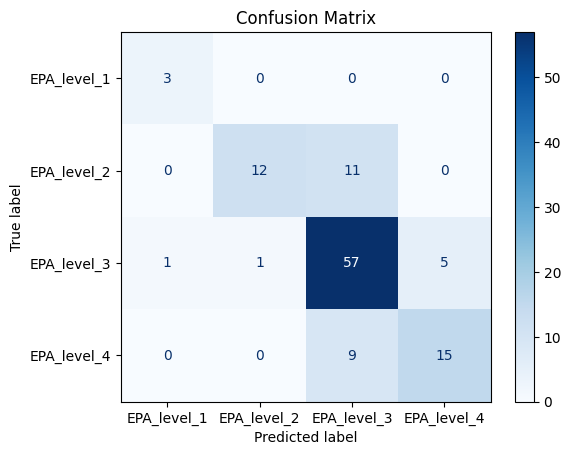

In [63]:
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [64]:
# Assume embedding_cols is defined as in your training code
# And mini_test_smiles is a DataFrame with one row from ChemNet_of_df3_QQpos_epalevels

# After you prepare X_train for training:
expected_cols = X_train.columns.tolist()

# Select only numeric columns from mini_test_smiles
X_single = mini_test_smiles.select_dtypes(include=[np.number])

# Convert columns to string (if needed)
X_single.columns = X_single.columns.astype(str)

# Reindex to match the training columns (fill missing with 0)
X_single = X_single.reindex(columns=expected_cols, fill_value=0)

# Predict EPA level
predicted_epa_level = rf3.predict(X_single)
print("Predicted EPA level:", predicted_epa_level[0])

Predicted EPA level: EPA_level_3


In [65]:
# If your EPA level columns are one-hot encoded
epa_level_cols = [col for col in mini_test_smiles.columns if str(col).startswith('EPA_level_')]
true_epa_level = mini_test_smiles[epa_level_cols].idxmax(axis=1).values[0]
print("True EPA level:", true_epa_level)

True EPA level: EPA_level_2


### Tune an RF

Fitting 5 folds for each of 24 candidates, totalling 120 fits


[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.7s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.7s
[CV] END max_depth=None, max_features=log2, n_estimators=300; total time=   0.8s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, max

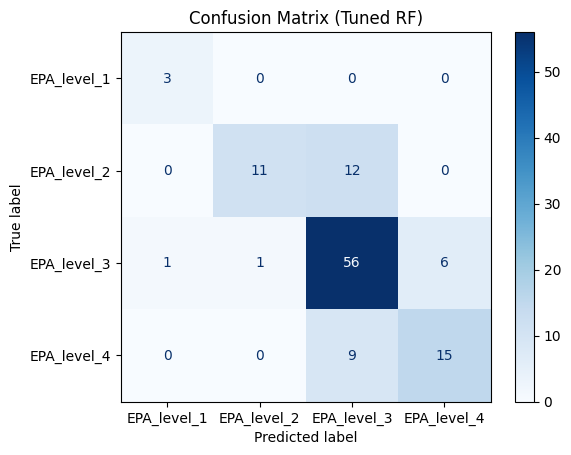

In [66]:
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=47)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', # Use macro F1 score for multi-class classification
    n_jobs=-1,
    verbose=2
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Use the best estimator to predict and evaluate
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Tuned RF)")
plt.show()


### Binary RF

In [67]:
# Combine EPA_level_1 and EPA_level_2 into EPA_level_1_2, remove EPA_level_3, keep only EPA_level_1_2 and EPA_level_4
df = test_output_df_withEPA.copy()

# Create new binary label
def combine_epa_levels(row):
    if row.get('EPA_level_1', 0) == 1 or row.get('EPA_level_2', 0) == 1:
        return 'EPA_level_1_2'
    elif row.get('EPA_level_4', 0) == 1:
        return 'EPA_level_4'
    else:
        return None  # EPA_level_3 or anything else

df['EPA_binary'] = df.apply(combine_epa_levels, axis=1)

# Filter out rows that are not EPA_level_1_2 or EPA_level_4
df_bin = df[df['EPA_binary'].isin(['EPA_level_1_2', 'EPA_level_4'])].copy()

# Prepare features and labels
embedding_cols = [
    col for col in df_bin.columns
    if col not in ['SMILES', 'SMILES_spectra', 'EPA_binary'] and not str(col).startswith('EPA_level_')
]

# Only keep numeric columns for features
X_bin = df_bin[embedding_cols].select_dtypes(include=[np.number])
X_bin.columns = X_bin.columns.astype(str)
y_bin = df_bin['EPA_binary']

# Train/test split
from sklearn.model_selection import train_test_split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

rf_bin = RandomForestClassifier(n_estimators=100, random_state=47)
rf_bin.fit(X_train_bin, y_train_bin)

# Predict and evaluate
y_pred_bin = rf_bin.predict(X_test_bin)
print(confusion_matrix(y_test_bin, y_pred_bin))

[[26  0]
 [ 5 19]]


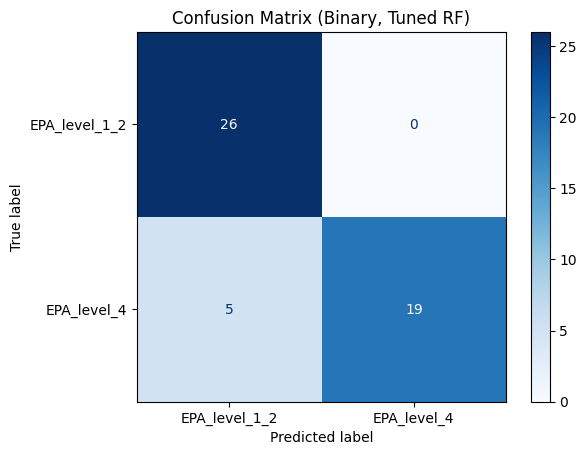

In [68]:
# Confusion matrix for binary classification
cm_bin = confusion_matrix(y_test_bin, y_pred_bin, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Binary, Tuned RF)")
plt.show()

In [69]:
# Assume embedding_cols is defined as in your training code
# And mini_test_smiles is a DataFrame with one row from ChemNet_of_df3_QQpos_epalevels

# After you prepare X_train for training:
expected_cols = X_train.columns.tolist()

# Select only numeric columns from mini_test_smiles
X_single = mini_test_smiles.select_dtypes(include=[np.number])

# Convert columns to string (if needed)
X_single.columns = X_single.columns.astype(str)

# Reindex to match the training columns (fill missing with 0)
X_single = X_single.reindex(columns=expected_cols, fill_value=0)

# Predict EPA level
predicted_epa_level = rf_bin.predict(X_single)
print("Predicted EPA level:", predicted_epa_level[0])

Predicted EPA level: EPA_level_1_2


In [70]:
# Prepare the features for the random forest from super_output_df (same columns as used for RF training)
X_super_rf = super_output_df[embedding_cols].select_dtypes(include=[np.number])
X_super_rf.columns = X_super_rf.columns.astype(str)

# Predict EPA level using your trained random forest
predicted_epa_levels_super = rf_bin.predict(X_super_rf)
print("Predicted EPA levels for super_output_df:", predicted_epa_levels_super)

Predicted EPA levels for super_output_df: ['EPA_level_1_2' 'EPA_level_1_2' 'EPA_level_1_2' 'EPA_level_1_2'
 'EPA_level_1_2' 'EPA_level_1_2' 'EPA_level_1_2' 'EPA_level_1_2'
 'EPA_level_1_2' 'EPA_level_4']


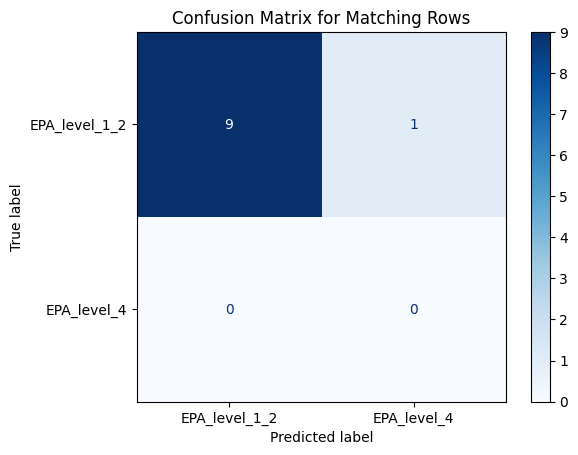

In [71]:
# Set all true labels to 'EPA_level_1_2'
y_true = ['EPA_level_1_2'] * len(X_super_rf)

# Predict EPA level using your trained random forest
y_pred = rf_bin.predict(X_super_rf)

# Create and display the confusion matrix
labels = ['EPA_level_1_2', 'EPA_level_4']
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Matching Rows")
plt.show()

Text(0.5, 1.0, 'Confusion Matrix for Matching Rows (4-way)')

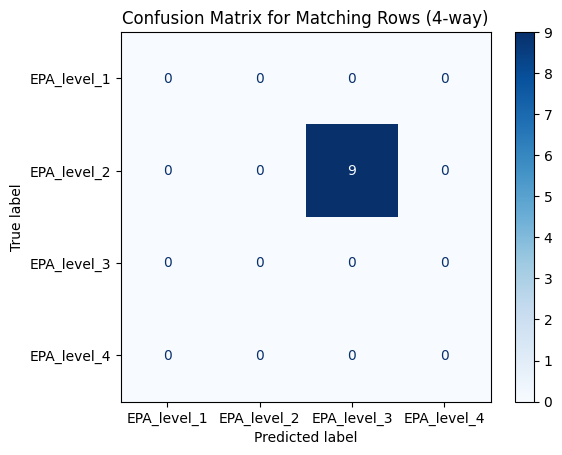

In [72]:
# Set all true labels to 'EPA_level_1' for all rows (or use the correct true label if known)
y_true = ['EPA_level_2'] * len(X_super_rf)  # Change to the correct label if needed

# Predict EPA level using your 4-class random forest
y_pred = rf3.predict(X_super_rf)

# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Create and display the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Matching Rows (4-way)")

### Balanced Random Forest 

We have a number of ways that we can introduce balance to a random forest. Undersampling and oversampling are the most basic, and can be used in combination as well, undersampling the majority class and oversampling the minority classes.

In [88]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Prepare features (X) and labels (y) as before
X = test_output_df_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_output_df_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 30
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
print(confusion_matrix(y_test_bal, y_pred_bal))

[[6 0 0 0]
 [0 3 1 2]
 [0 3 3 0]
 [0 1 1 4]]


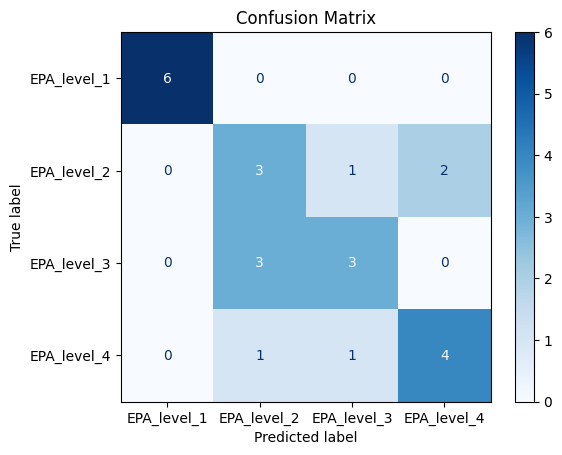

In [89]:
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Text(0.5, 1.0, 'Confusion Matrix for Matching Rows (4-way)')

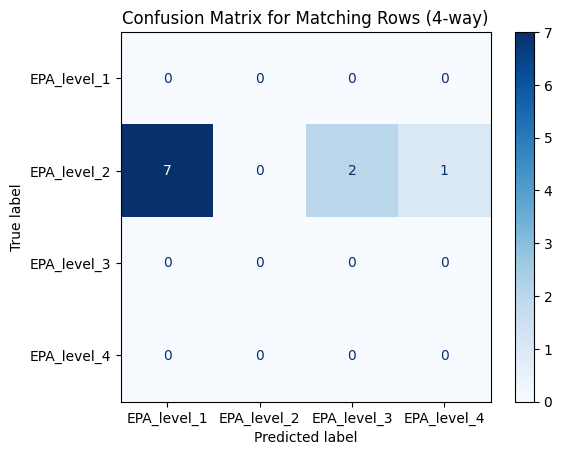

In [90]:
# Balanced RF on the super_testing spectra
y_true = ['EPA_level_2'] * len(X_super_rf)  # Change to the correct label if needed

# Predict EPA level using your 4-class random forest
y_pred = rf_bal.predict(X_super_rf)

# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Create and display the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Matching Rows (4-way)")